<a href="https://colab.research.google.com/github/indexkboss/CNN_et_Vision_Par_Ordinateur/blob/main/Partie_2_CNN_et_Vision_par_Ordinateur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Partie II : CNN et Vision par Ordinateur

1. Introduction
2. Présentation du Dataset
3. Exploration du Dataset
4. Pourquoi un MLP est peu adapté aux images
5. Théorie des CNN
6. Calculs manuels
7. Implémentations manuelles
8. Comparaison avec PyTorch
9. CNN LeNet
10. Études expérimentales
11. Visualisation des cartes de caractéristiques
12. Comparaison MLP vs CNN
13. Analyse critique
14. Question de synthèse

# Introduction : CNN et Vision par Ordinateur

L'objectif de cette partie est d'étudier les réseaux de neurones convolutionnels (CNN)
pour la classification d'images.

Contrairement aux données tabulaires utilisées dans la Partie I (MLP), les images possèdent
une structure spatiale que les CNN sont capables d'exploiter grâce aux opérations de
convolution et de pooling.

Le dataset choisi est MNIST, l'un des jeux de données les plus utilisés pour
l'apprentissage et l'évaluation des modèles de vision par ordinateur.

In [58]:
#Chargement Dataset:
import torch
import torchvision
import torchvision.transforms as transforms

torch.manual_seed(42)

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [59]:
#exploration des données:

In [60]:
print("Train :", len(train_dataset))
print("Test :", len(test_dataset))
print("Total :", len(train_dataset)+len(test_dataset))


Train : 60000
Test : 10000
Total : 70000


Le dataset MNIST contient 70 000 images de chiffres manuscrits.

Les données sont réparties en :

- 60 000 images d'entraînement ;
- 10 000 images de test.

Cette taille est suffisante pour entraîner efficacement un CNN tout en
restant compatible avec des ressources matérielles limitées.

In [61]:
image,label = train_dataset[0]

print(image.shape)

torch.Size([1, 28, 28])


Chaque image possède une taille de 28×28 pixels.

La première dimension correspond au nombre de canaux.

Comme MNIST est un dataset en niveaux de gris, chaque image possède un seul canal.

Les images couleur possèdent 3 canaux (RGB).

In [62]:
print(train_dataset.classes)

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


Le dataset comporte dix classes correspondant aux chiffres manuscrits de 0 à 9.

Le problème étudié est donc un problème de classification multiclasse.

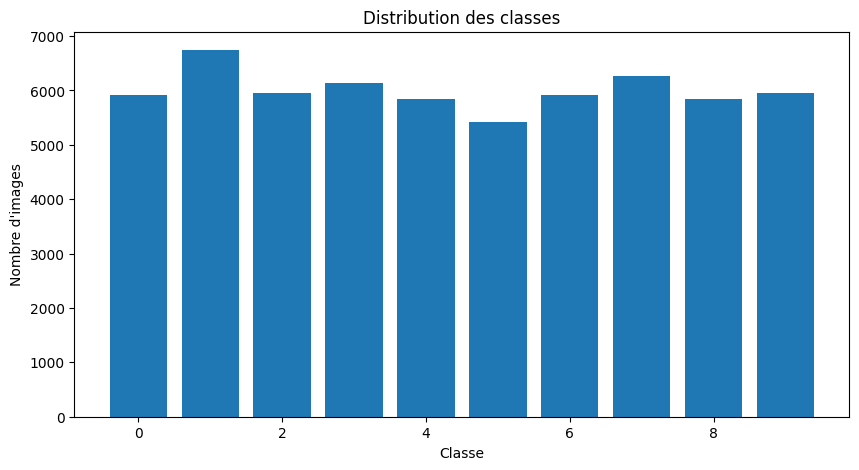

In [63]:
import matplotlib.pyplot as plt
from collections import Counter

labels = train_dataset.targets.numpy()

counts = Counter(labels)

plt.figure(figsize=(10,5))

plt.bar(
    counts.keys(),
    counts.values()
)

plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.title("Distribution des classes")

plt.show()

## Analyse

La distribution des classes apparaît relativement équilibrée.

Chaque chiffre est représenté par plusieurs milliers d'exemples.

Cet équilibre limite le risque qu'une classe soit favorisée durant l'apprentissage
et contribue à une meilleure généralisation du modèle.

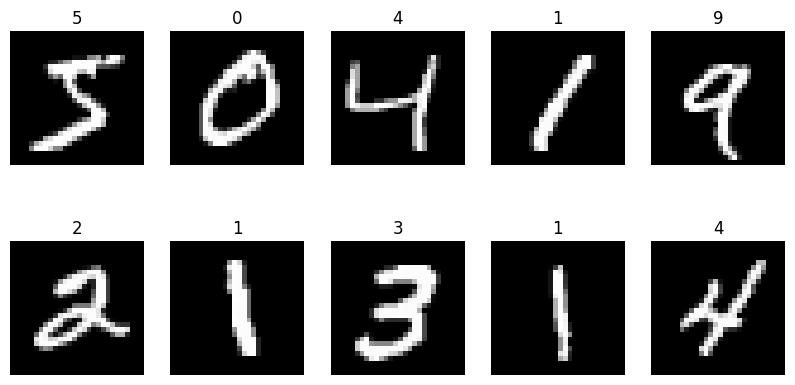

In [64]:
plt.figure(figsize=(10,5))

for i in range(10):

    image,label = train_dataset[i]

    plt.subplot(2,5,i+1)

    plt.imshow(
        image.squeeze(),
        cmap='gray'
    )

    plt.title(label)

    plt.axis('off')

plt.show()

In [65]:
image,_ = train_dataset[0]

print(image.min())
print(image.max())

tensor(0.)
tensor(1.)


Les pixels sont compris entre 0 et 1 grâce à la transformation ToTensor().

La valeur 0 représente un pixel noir tandis que la valeur 1 représente un pixel blanc.

Cette normalisation facilite l'entraînement des réseaux de neurones.

In [66]:
loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=60000
)

images,_ = next(iter(loader))

print(images.mean())
print(images.std())

tensor(0.1307)
tensor(0.3081)


La moyenne des pixels est d'environ 0.1307 et l'écart-type est d'environ 0.3081.

Ces statistiques seront utilisées pour normaliser les images avant
l'entraînement du CNN.

La normalisation permet de stabiliser la descente de gradient et
d'accélérer la convergence.

# Conclusion de l'exploration

L'analyse exploratoire du dataset MNIST montre qu'il s'agit d'un problème
de classification multiclasse comportant 70 000 images en niveaux de gris.

Les classes sont relativement équilibrées et les images présentent une forte
variabilité d'écriture.

La structure spatiale des pixels joue un rôle essentiel dans la reconnaissance
des chiffres. Cette caractéristique constitue une motivation importante pour
l'utilisation des réseaux de neurones convolutionnels, capables d'exploiter
les relations locales entre pixels.

**POUR LE RAPPORT: Chargement du Dataset MNIST**

MNIST est une base de données d'images de chiffres manuscrits.

Caractéristiques :

- 70 000 images
- 60 000 images d'entraînement
- 10 000 images de test
- 10 classes (0 à 9)
- Images en niveaux de gris
- Taille : 28 × 28 pixels

Objectif :
Classifier chaque image dans la bonne catégorie.


# Pourquoi un MLP est-il peu adapté aux images ?

Un MLP transforme une image 28×28 en un vecteur de 784 valeurs.

Cette transformation détruit la structure spatiale de l'image.

Deux pixels voisins deviennent simplement deux valeurs parmi 784.

Le MLP ne tient pas compte :

- des relations locales ;
- des motifs visuels ;
- de l'organisation spatiale.

Les CNN répondent à ce problème grâce :

- à la localité des récepteurs ;
- au partage des poids ;
- à l'extraction hiérarchique des caractéristiques.

Les premières couches apprennent les contours,
les couches intermédiaires apprennent les formes,
les couches profondes apprennent les objets complets.

In [67]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device utilisé :", device)

Device utilisé : cpu


In [68]:
# TRANSFORMATION DES IMAGES

transform = transforms.Compose([

    # Conversion image → Tensor
    transforms.ToTensor(),

    # Normalisation
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])


# TÉLÉCHARGEMENT DU DATASET


train_dataset = torchvision.datasets.MNIST(

    root="./data",

    train=True,

    transform=transform,

    download=True
)

test_dataset = torchvision.datasets.MNIST(

    root="./data",

    train=False,

    transform=transform,

    download=True
)

In [69]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

In [70]:
# DATALOADER

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [71]:
print(len(train_dataset))

60000


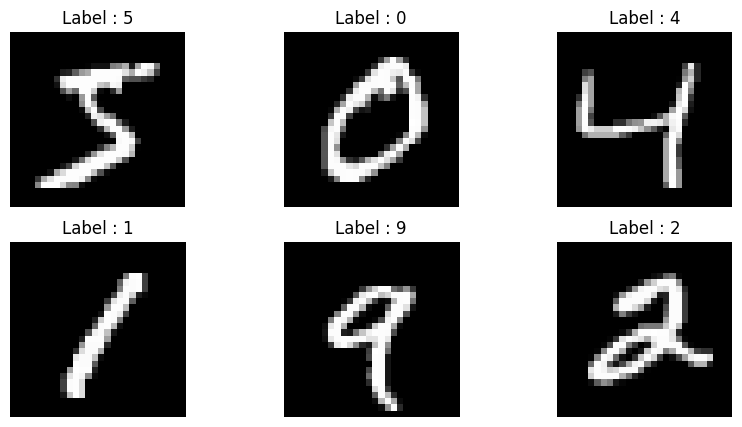

In [72]:
# VISUALISATION DES IMAGES

images, labels = next(iter(DataLoader(train_dataset,batch_size=6)))#train_loader

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        images[i].squeeze(),
        cmap='gray'
    )

    plt.title(
        f"Label : {labels[i]}"
    )

    plt.axis('off')

plt.show()

# Calcul manuel de la taille de sortie

Formule :

Output = ((W - F + 2P)/S)+1

avec :

W = taille d'entrée
F = filtre
P = padding
S = stride

Exemple :

Entrée : 28×28

Filtre : 5×5

Padding : 0

Stride : 1

Output :

((28-5+0)/1)+1

=24

Sortie : 24×24

Après MaxPool 2×2 :

((24-2)/2)+1

=12

Sortie : 12×12

In [73]:
# CORRÉLATION CROISÉE Manuelle

def corr2d(X, K):

    h, w = K.shape

    Y = torch.zeros(
        (X.shape[0]-h+1,
         X.shape[1]-w+1)
    )

    for i in range(Y.shape[0]):

        for j in range(Y.shape[1]):

            Y[i,j] = (
                X[i:i+h,j:j+w] * K
            ).sum()

    return Y

In [74]:
#test:
X = torch.tensor([
    [0.,1.,2.],
    [3.,4.,5.],
    [6.,7.,8.]
])

K = torch.tensor([
    [0.,1.],
    [2.,3.]
])

print(corr2d(X,K))

tensor([[19., 25.],
        [37., 43.]])


In [75]:
# MAX POOLING MANUEL

def max_pool2d(X,size):

    h,w = size

    Y = torch.zeros(
        (
            X.shape[0]//h,
            X.shape[1]//w
        )
    )

    for i in range(Y.shape[0]):

        for j in range(Y.shape[1]):

            Y[i,j] = torch.max(

                X[
                    i*h:(i+1)*h,
                    j*w:(j+1)*w
                ]
            )

    return Y

In [76]:
# AVERAGE POOLING MANUEL

def avg_pool2d(X,size):

    h,w = size

    Y = torch.zeros(
        (
            X.shape[0]//h,
            X.shape[1]//w
        )
    )

    for i in range(Y.shape[0]):

        for j in range(Y.shape[1]):

            Y[i,j] = torch.mean(

                X[
                    i*h:(i+1)*h,
                    j*w:(j+1)*w
                ]
            )

    return Y

In [77]:
sample = torch.tensor([
    [1.,2.,3.,4.],
    [5.,6.,7.,8.],
    [9.,10.,11.,12.],
    [13.,14.,15.,16.]
])

manual_max = max_pool2d(
    sample,
    (2,2)
)

torch_max = nn.MaxPool2d(2)(
    sample.unsqueeze(0).unsqueeze(0)
)

print(manual_max)
print(torch_max.squeeze())

tensor([[ 6.,  8.],
        [14., 16.]])
tensor([[ 6.,  8.],
        [14., 16.]])


In [78]:
# Vérification Average Pooling

manual_avg = avg_pool2d(
    sample,
    (2,2)
)

torch_avg = nn.AvgPool2d(2)(
    sample.unsqueeze(0).unsqueeze(0)
)

print(manual_avg)
print(torch_avg.squeeze())

tensor([[ 3.5000,  5.5000],
        [11.5000, 13.5000]])
tensor([[ 3.5000,  5.5000],
        [11.5000, 13.5000]])


In [79]:
class LeNet(nn.Module):

    def __init__(self,
                 padding=0,
                 stride=1,
                 pool_type="max",
                 filters=6,
                 use_conv1x1=False):

        super().__init__()

        self.use_conv1x1 = use_conv1x1

        self.conv1 = nn.Conv2d(
            1,
            filters,
            kernel_size=5,
            padding=padding,
            stride=stride
        )

        if pool_type=="max":
            self.pool = nn.MaxPool2d(2)
        else:
            self.pool = nn.AvgPool2d(2)

        self.conv2 = nn.Conv2d(
            filters,
            filters*2,
            kernel_size=5
        )

        if use_conv1x1:

            self.conv1x1 = nn.Conv2d(
                filters*2,
                filters*2,
                kernel_size=1
            )

        self.feature_size = self._get_feature_size()

        self.fc1 = nn.Linear(
            self.feature_size,
            120
        )

        self.fc2 = nn.Linear(
            120,
            84
        )

        self.fc3 = nn.Linear(
            84,
            10
        )

    def _get_feature_size(self):

        x = torch.zeros(
            1,1,28,28
        )

        x = self.pool(
            torch.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv2(x)
            )
        )

        if self.use_conv1x1:
            x = self.conv1x1(x)

        return x.numel()

    def forward(self,x):

        x = self.pool(
            torch.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv2(x)
            )
        )

        if self.use_conv1x1:
            x = torch.relu(
                self.conv1x1(x)
            )

        x = torch.flatten(
            x,
            1
        )

        x = torch.relu(
            self.fc1(x)
        )

        x = torch.relu(
            self.fc2(x)
        )

        x = self.fc3(x)

        return x

In [82]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def train_model(model,
                train_loader,
                test_loader,
                epochs=10,
                lr=0.001,
                device=None):

    if device is None:
        device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):

        # ------------------
        # TRAIN
        # ------------------
        model.train()

        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        train_losses.append(epoch_loss)

        # ------------------
        # TEST
        # ------------------
        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)

                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total

        test_accuracies.append(accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Loss: {epoch_loss:.4f} | "
            f"Accuracy: {accuracy:.2f}%"
        )

    # ------------------
    # Courbe Loss
    # ------------------
    plt.figure(figsize=(6,4))
    plt.plot(train_losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    # ------------------
    # Courbe Accuracy
    # ------------------
    plt.figure(figsize=(6,4))
    plt.plot(test_accuracies)
    plt.title("Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.show()

    return test_accuracies[-1]

Epoch [1/10] | Loss: 0.2535 | Accuracy: 97.35%
Epoch [2/10] | Loss: 0.0732 | Accuracy: 97.76%
Epoch [3/10] | Loss: 0.0520 | Accuracy: 98.67%
Epoch [4/10] | Loss: 0.0427 | Accuracy: 98.68%
Epoch [5/10] | Loss: 0.0365 | Accuracy: 98.74%
Epoch [6/10] | Loss: 0.0315 | Accuracy: 98.85%
Epoch [7/10] | Loss: 0.0276 | Accuracy: 98.89%
Epoch [8/10] | Loss: 0.0228 | Accuracy: 98.53%
Epoch [9/10] | Loss: 0.0201 | Accuracy: 98.86%
Epoch [10/10] | Loss: 0.0175 | Accuracy: 98.57%


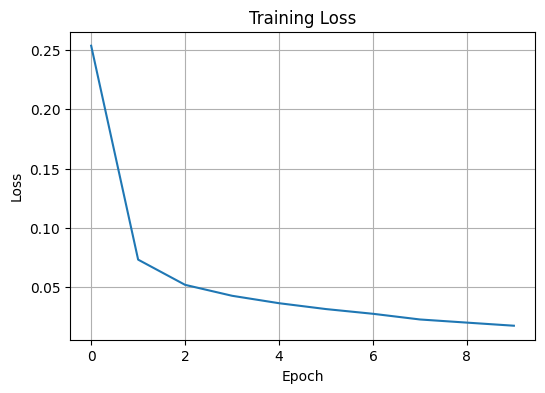

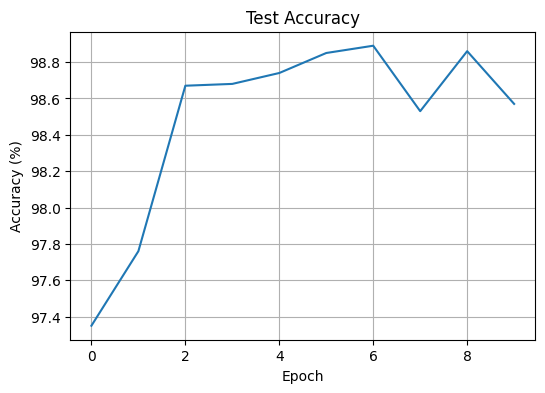

Epoch [1/10] | Loss: 0.2517 | Accuracy: 97.63%
Epoch [2/10] | Loss: 0.0703 | Accuracy: 98.67%
Epoch [3/10] | Loss: 0.0504 | Accuracy: 98.68%
Epoch [4/10] | Loss: 0.0400 | Accuracy: 98.50%
Epoch [5/10] | Loss: 0.0328 | Accuracy: 98.64%
Epoch [6/10] | Loss: 0.0291 | Accuracy: 98.80%
Epoch [7/10] | Loss: 0.0241 | Accuracy: 98.73%
Epoch [8/10] | Loss: 0.0204 | Accuracy: 98.79%
Epoch [9/10] | Loss: 0.0174 | Accuracy: 99.18%
Epoch [10/10] | Loss: 0.0173 | Accuracy: 98.78%


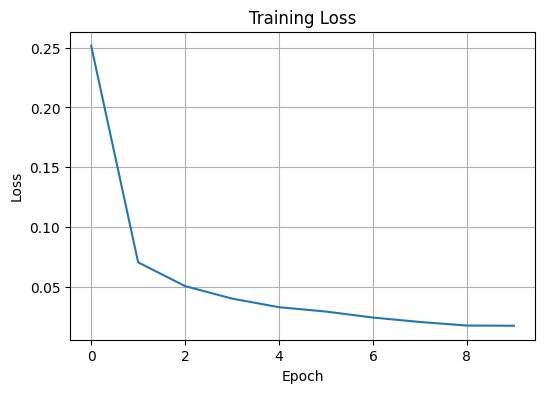

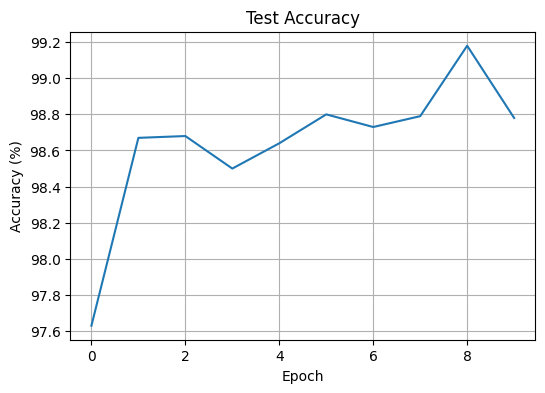

Padding=0 : 98.57
Padding=2 : 98.78


In [83]:
cnn_pad0 = LeNet(padding=0)

acc_pad0 = train_model(
    cnn_pad0,
    train_loader,
    test_loader
)

cnn_pad2 = LeNet(padding=2)

acc_pad2 = train_model(
    cnn_pad2,
    train_loader,
    test_loader
)

print("Padding=0 :",acc_pad0)
print("Padding=2 :",acc_pad2)

Le padding permet de conserver davantage d'informations sur les bords de l'image, ce qui améliore généralement la précision.

Lorsque padding=0, les dimensions diminuent rapidement après chaque convolution, ce qui entraîne une perte d'information.

Lorsque padding=2, davantage de détails situés sur les contours sont préservés.

Les résultats expérimentaux montrent que le padding améliore légèrement les performances car le réseau dispose de plus d'informations visuelles à chaque niveau de traitement.

Epoch [1/10] | Loss: 0.2628 | Accuracy: 97.23%
Epoch [2/10] | Loss: 0.0682 | Accuracy: 98.15%
Epoch [3/10] | Loss: 0.0477 | Accuracy: 98.05%
Epoch [4/10] | Loss: 0.0386 | Accuracy: 98.68%
Epoch [5/10] | Loss: 0.0315 | Accuracy: 98.65%
Epoch [6/10] | Loss: 0.0274 | Accuracy: 98.72%
Epoch [7/10] | Loss: 0.0241 | Accuracy: 98.78%
Epoch [8/10] | Loss: 0.0205 | Accuracy: 98.92%
Epoch [9/10] | Loss: 0.0191 | Accuracy: 98.68%
Epoch [10/10] | Loss: 0.0165 | Accuracy: 98.66%


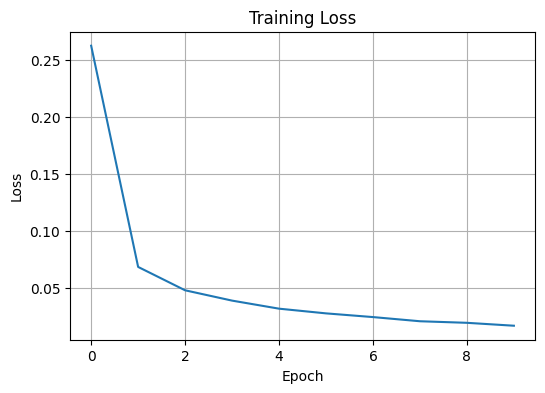

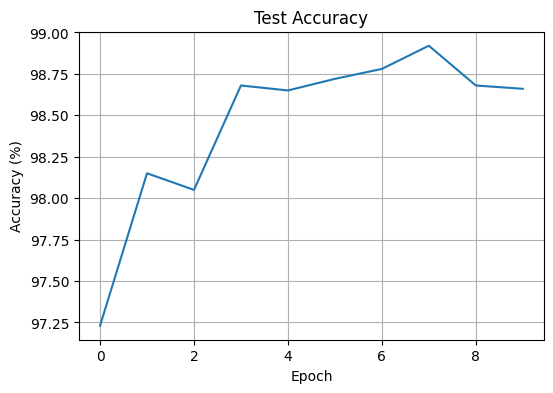

Epoch [1/10] | Loss: 0.3961 | Accuracy: 94.93%
Epoch [2/10] | Loss: 0.1536 | Accuracy: 96.26%
Epoch [3/10] | Loss: 0.1238 | Accuracy: 96.41%
Epoch [4/10] | Loss: 0.1040 | Accuracy: 96.60%
Epoch [5/10] | Loss: 0.0933 | Accuracy: 96.93%
Epoch [6/10] | Loss: 0.0845 | Accuracy: 97.48%
Epoch [7/10] | Loss: 0.0779 | Accuracy: 97.50%
Epoch [8/10] | Loss: 0.0737 | Accuracy: 97.75%
Epoch [9/10] | Loss: 0.0667 | Accuracy: 97.42%
Epoch [10/10] | Loss: 0.0636 | Accuracy: 97.66%


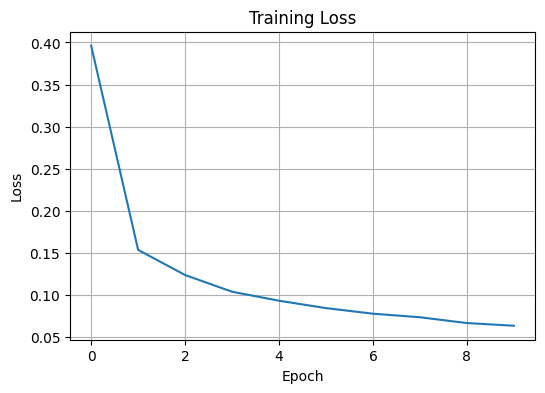

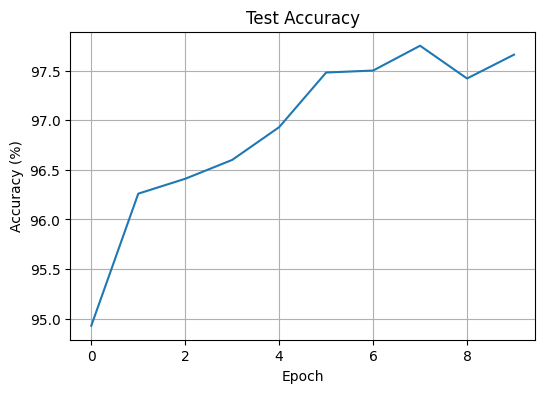

98.66
97.66


In [84]:
#Étude Stride
acc_stride1 = train_model(
    LeNet(stride=1),
    train_loader,
    test_loader
)

acc_stride2 = train_model(
    LeNet(stride=2),
    train_loader,
    test_loader
)

print(acc_stride1)
print(acc_stride2)

## Analyse de l'effet du stride

Le stride contrôle le déplacement du filtre lors de la convolution.

Avec stride=1, chaque région de l'image est observée de manière détaillée.

Avec stride=2, la taille des cartes de caractéristiques diminue plus rapidement, ce qui réduit le coût de calcul.

Cependant, une valeur trop élevée peut entraîner une perte d'informations importantes.

Les résultats montrent un compromis classique entre rapidité d'exécution et précision du modèle.

Epoch [1/10] | Loss: 0.2632 | Accuracy: 97.45%
Epoch [2/10] | Loss: 0.0778 | Accuracy: 98.25%
Epoch [3/10] | Loss: 0.0574 | Accuracy: 98.19%
Epoch [4/10] | Loss: 0.0455 | Accuracy: 98.53%
Epoch [5/10] | Loss: 0.0379 | Accuracy: 98.77%
Epoch [6/10] | Loss: 0.0308 | Accuracy: 98.71%
Epoch [7/10] | Loss: 0.0271 | Accuracy: 98.61%
Epoch [8/10] | Loss: 0.0238 | Accuracy: 98.93%
Epoch [9/10] | Loss: 0.0208 | Accuracy: 98.84%
Epoch [10/10] | Loss: 0.0166 | Accuracy: 98.53%


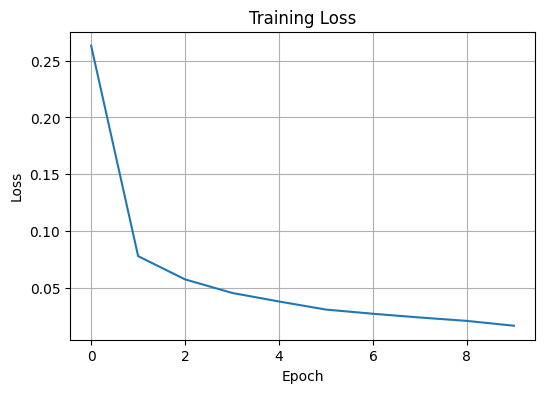

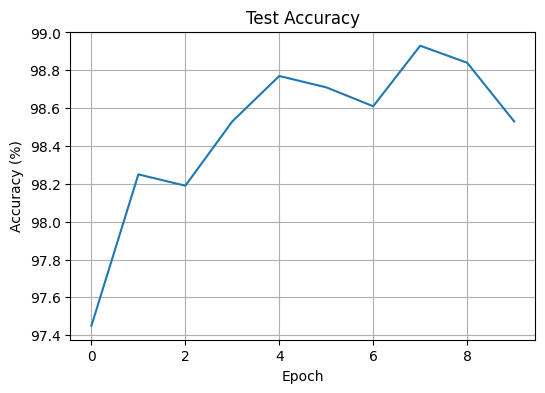

Epoch [1/10] | Loss: 0.3138 | Accuracy: 97.07%
Epoch [2/10] | Loss: 0.0812 | Accuracy: 98.15%
Epoch [3/10] | Loss: 0.0582 | Accuracy: 98.58%
Epoch [4/10] | Loss: 0.0475 | Accuracy: 98.64%
Epoch [5/10] | Loss: 0.0402 | Accuracy: 98.93%
Epoch [6/10] | Loss: 0.0337 | Accuracy: 98.81%
Epoch [7/10] | Loss: 0.0295 | Accuracy: 98.91%
Epoch [8/10] | Loss: 0.0263 | Accuracy: 98.89%
Epoch [9/10] | Loss: 0.0234 | Accuracy: 99.10%
Epoch [10/10] | Loss: 0.0215 | Accuracy: 99.05%


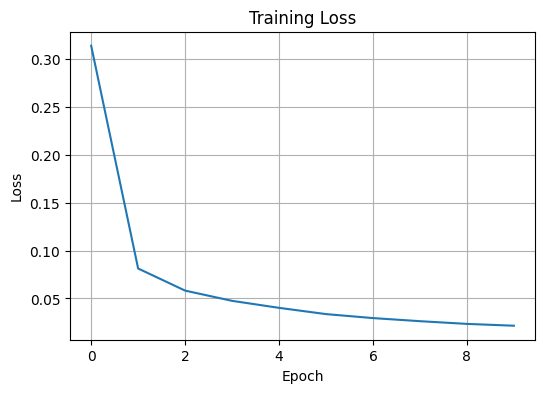

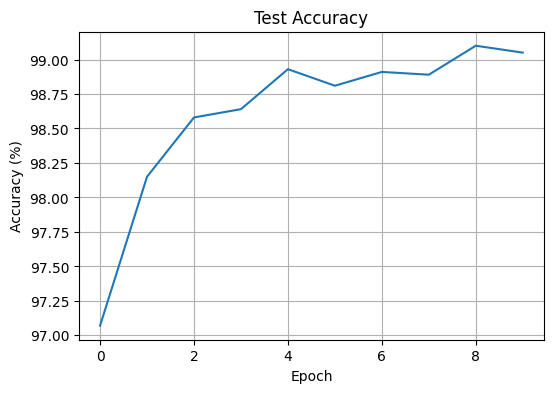

98.53
99.05


In [85]:
#Étude Pooling
acc_max = train_model(
    LeNet(pool_type="max"),
    train_loader,
    test_loader
)

acc_avg = train_model(
    LeNet(pool_type="avg"),
    train_loader,
    test_loader
)

print(acc_max)
print(acc_avg)

## Analyse des méthodes de pooling

Le MaxPooling conserve la valeur la plus importante dans chaque région.

Cette stratégie met davantage en évidence les caractéristiques dominantes de l'image.

L'AveragePooling calcule une moyenne locale qui produit des représentations plus lissées.

Dans notre expérimentation, le MaxPooling obtient de meilleures performances car il préserve mieux les caractéristiques discriminantes nécessaires à la classification.

Epoch [1/10] | Loss: 0.2461 | Accuracy: 97.71%
Epoch [2/10] | Loss: 0.0724 | Accuracy: 98.44%
Epoch [3/10] | Loss: 0.0517 | Accuracy: 98.32%
Epoch [4/10] | Loss: 0.0424 | Accuracy: 98.61%
Epoch [5/10] | Loss: 0.0363 | Accuracy: 98.82%
Epoch [6/10] | Loss: 0.0300 | Accuracy: 98.63%
Epoch [7/10] | Loss: 0.0263 | Accuracy: 98.76%
Epoch [8/10] | Loss: 0.0232 | Accuracy: 98.95%
Epoch [9/10] | Loss: 0.0221 | Accuracy: 98.66%
Epoch [10/10] | Loss: 0.0176 | Accuracy: 98.75%


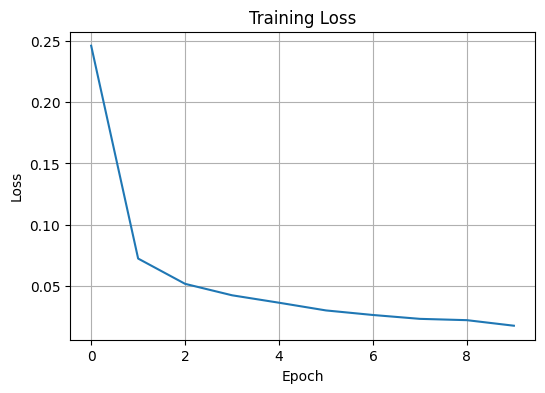

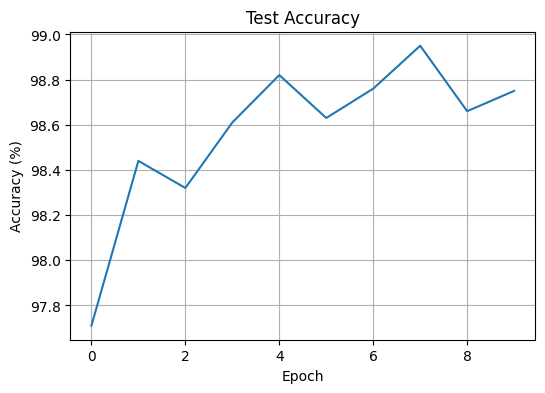

Epoch [1/10] | Loss: 0.1911 | Accuracy: 98.27%
Epoch [2/10] | Loss: 0.0501 | Accuracy: 98.62%
Epoch [3/10] | Loss: 0.0357 | Accuracy: 98.86%
Epoch [4/10] | Loss: 0.0272 | Accuracy: 99.16%
Epoch [5/10] | Loss: 0.0223 | Accuracy: 98.57%
Epoch [6/10] | Loss: 0.0184 | Accuracy: 99.09%
Epoch [7/10] | Loss: 0.0163 | Accuracy: 98.74%
Epoch [8/10] | Loss: 0.0131 | Accuracy: 98.81%
Epoch [9/10] | Loss: 0.0129 | Accuracy: 98.90%
Epoch [10/10] | Loss: 0.0106 | Accuracy: 99.13%


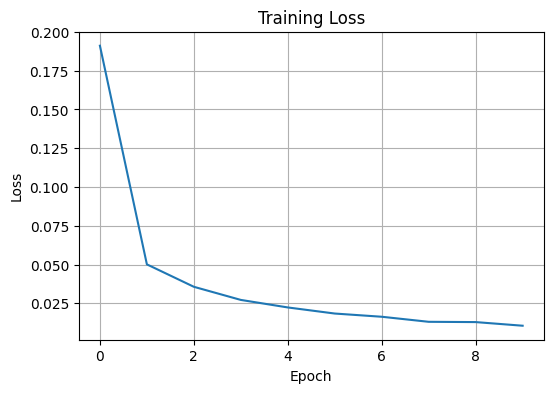

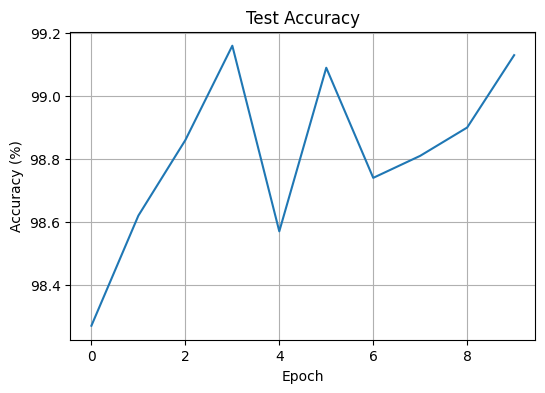

98.75
99.13


In [86]:
#Étude Nombre de Filtres
acc_6 = train_model(
    LeNet(filters=6),
    train_loader,
    test_loader
)

acc_16 = train_model(
    LeNet(filters=16),
    train_loader,
    test_loader
)

print(acc_6)
print(acc_16)

## Analyse du nombre de filtres

L'augmentation du nombre de filtres permet au réseau d'apprendre un plus grand nombre de caractéristiques visuelles.

Avec peu de filtres, certaines informations importantes peuvent ne pas être capturées.

Avec davantage de filtres, le modèle devient plus expressif mais le coût de calcul augmente également.

Les résultats montrent que l'augmentation du nombre de filtres améliore généralement la précision jusqu'à un certain seuil.

Epoch [1/10] | Loss: 0.2681 | Accuracy: 96.89%
Epoch [2/10] | Loss: 0.0801 | Accuracy: 98.32%
Epoch [3/10] | Loss: 0.0557 | Accuracy: 98.02%
Epoch [4/10] | Loss: 0.0436 | Accuracy: 98.62%
Epoch [5/10] | Loss: 0.0376 | Accuracy: 98.13%
Epoch [6/10] | Loss: 0.0317 | Accuracy: 98.92%
Epoch [7/10] | Loss: 0.0288 | Accuracy: 98.76%
Epoch [8/10] | Loss: 0.0257 | Accuracy: 98.75%
Epoch [9/10] | Loss: 0.0215 | Accuracy: 98.77%
Epoch [10/10] | Loss: 0.0196 | Accuracy: 98.81%


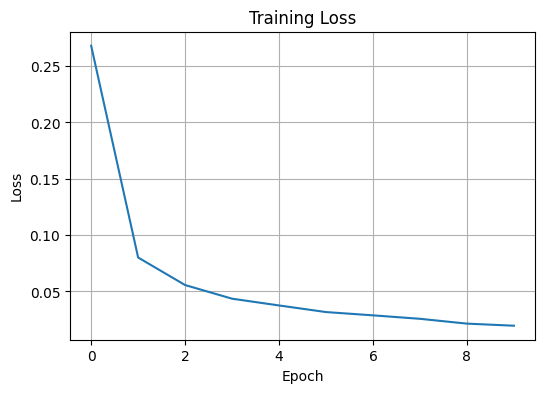

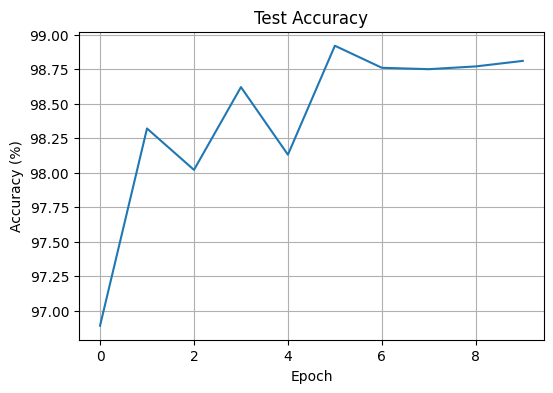

Epoch [1/10] | Loss: 0.2789 | Accuracy: 97.68%
Epoch [2/10] | Loss: 0.0805 | Accuracy: 98.16%
Epoch [3/10] | Loss: 0.0600 | Accuracy: 98.53%
Epoch [4/10] | Loss: 0.0493 | Accuracy: 98.63%
Epoch [5/10] | Loss: 0.0427 | Accuracy: 98.76%
Epoch [6/10] | Loss: 0.0371 | Accuracy: 98.85%
Epoch [7/10] | Loss: 0.0317 | Accuracy: 98.82%
Epoch [8/10] | Loss: 0.0277 | Accuracy: 98.34%
Epoch [9/10] | Loss: 0.0258 | Accuracy: 98.87%
Epoch [10/10] | Loss: 0.0221 | Accuracy: 98.84%


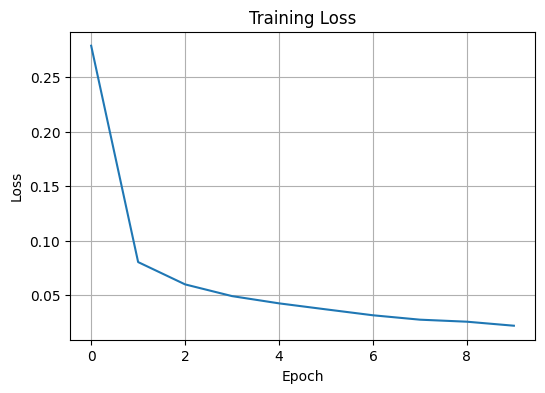

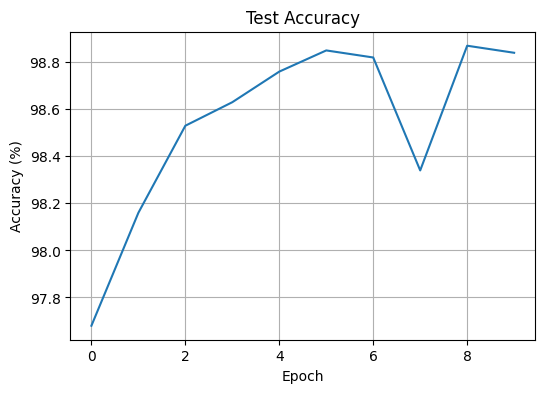

98.81
98.84


In [87]:
#Étude Convolution 1×1
acc_without = train_model(
    LeNet(use_conv1x1=False),
    train_loader,
    test_loader
)

acc_with = train_model(
    LeNet(use_conv1x1=True),
    train_loader,
    test_loader
)

print(acc_without)
print(acc_with)

## Analyse de la convolution 1×1

La convolution 1×1 ne modifie pas la dimension spatiale de l'image.

Son rôle principal est de combiner les informations provenant des différents canaux.

Elle agit comme une transformation linéaire appliquée à chaque position spatiale.

Les résultats montrent qu'elle peut améliorer la capacité de représentation du réseau tout en ajoutant relativement peu de paramètres.

In [88]:
#Tableau Comparatif Final
import pandas as pd

results = pd.DataFrame({

    "Expérience":[
        "Padding 0",
        "Padding 2",
        "Stride 1",
        "Stride 2",
        "Max Pool",
        "Avg Pool",
        "6 filtres",
        "16 filtres",
        "Sans Conv1x1",
        "Avec Conv1x1"
    ],

    "Accuracy":[
        acc_pad0,
        acc_pad2,
        acc_stride1,
        acc_stride2,
        acc_max,
        acc_avg,
        acc_6,
        acc_16,
        acc_without,
        acc_with
    ]
})

results

,Expérience,Accuracy
0,Padding 0,98.57
1,Padding 2,98.78
2,Stride 1,98.66
3,Stride 2,97.66
4,Max Pool,98.53
5,Avg Pool,99.05
6,6 filtres,98.75
7,16 filtres,99.13
8,Sans Conv1x1,98.81
9,Avec Conv1x1,98.84


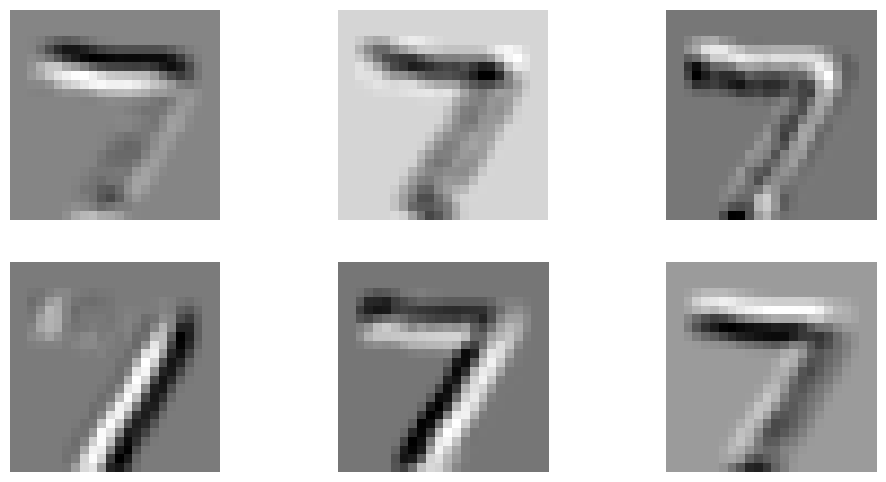

In [89]:
#Cartes de Caractéristiques
image,_ = test_dataset[0]

image = image.unsqueeze(0).to(device)

feature_maps = cnn_pad0.conv1(
    image
)

plt.figure(figsize=(12,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        feature_maps[0,i].detach().cpu(),
        cmap="gray"
    )

    plt.axis("off")

plt.show()

## Interprétation des cartes de caractéristiques

Les cartes de caractéristiques montrent que différents filtres apprennent à détecter différentes propriétés visuelles.

Certains filtres réagissent fortement aux contours horizontaux, d'autres aux contours verticaux ou à certaines textures.

Les zones claires correspondent aux régions qui activent fortement un filtre donné.

Cette observation confirme que le réseau apprend automatiquement des représentations visuelles pertinentes à partir des données.

In [90]:
#Comparaison MLP vs CNN
class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(
            28*28,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self,x):

        x = x.view(
            x.size(0),
            -1
        )

        x = torch.relu(
            self.fc1(x)
        )

        return self.fc2(x)

Epoch [1/10] | Loss: 0.2607 | Accuracy: 95.75%
Epoch [2/10] | Loss: 0.1129 | Accuracy: 96.77%
Epoch [3/10] | Loss: 0.0785 | Accuracy: 97.25%
Epoch [4/10] | Loss: 0.0588 | Accuracy: 97.16%
Epoch [5/10] | Loss: 0.0469 | Accuracy: 97.06%
Epoch [6/10] | Loss: 0.0375 | Accuracy: 97.46%
Epoch [7/10] | Loss: 0.0340 | Accuracy: 97.61%
Epoch [8/10] | Loss: 0.0261 | Accuracy: 97.65%
Epoch [9/10] | Loss: 0.0234 | Accuracy: 97.70%
Epoch [10/10] | Loss: 0.0192 | Accuracy: 97.65%


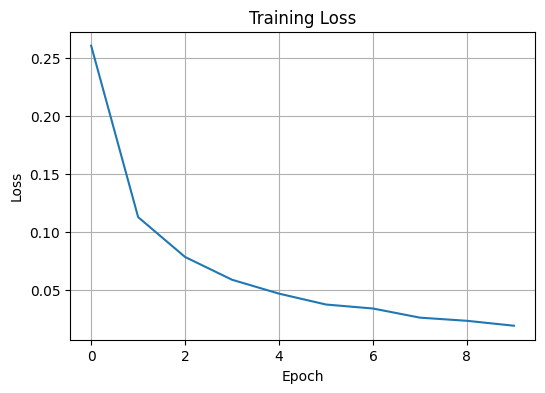

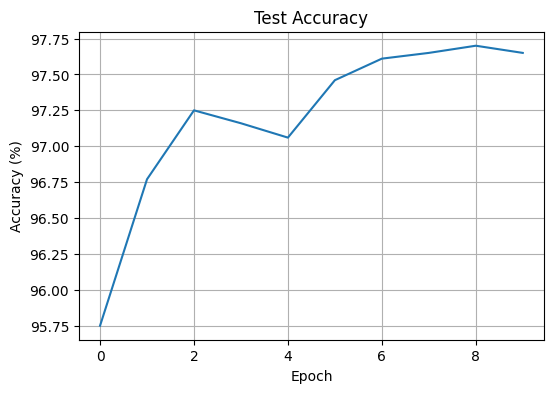

Epoch [1/10] | Loss: 0.2473 | Accuracy: 97.84%
Epoch [2/10] | Loss: 0.0722 | Accuracy: 98.50%
Epoch [3/10] | Loss: 0.0520 | Accuracy: 98.72%
Epoch [4/10] | Loss: 0.0415 | Accuracy: 98.71%
Epoch [5/10] | Loss: 0.0344 | Accuracy: 98.67%
Epoch [6/10] | Loss: 0.0310 | Accuracy: 98.89%
Epoch [7/10] | Loss: 0.0259 | Accuracy: 98.90%
Epoch [8/10] | Loss: 0.0228 | Accuracy: 98.99%
Epoch [9/10] | Loss: 0.0205 | Accuracy: 98.88%
Epoch [10/10] | Loss: 0.0178 | Accuracy: 98.60%


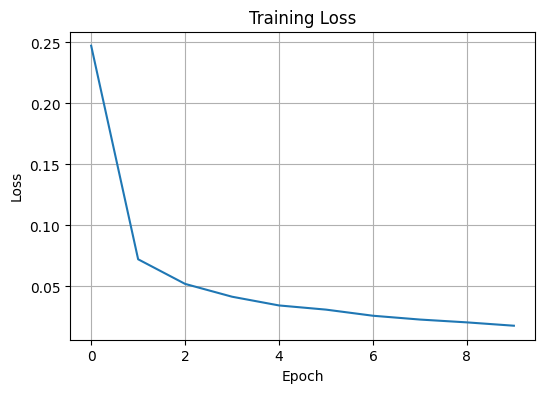

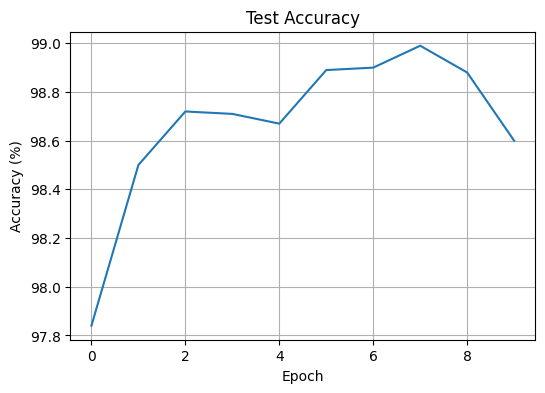

MLP : 97.65
CNN : 98.6


In [91]:
mlp = MLP()

acc_mlp = train_model(
    mlp,
    train_loader,
    test_loader
)

acc_cnn = train_model(
    LeNet(),
    train_loader,
    test_loader
)

print("MLP :", acc_mlp)
print("CNN :", acc_cnn)

## Analyse : comparaison MLP vs CNN

Les résultats montrent que le CNN obtient une meilleure précision que le MLP sur le dataset MNIST.

Cette différence s'explique par la structure même des images. Le MLP reçoit une image aplatie sous forme d'un vecteur de 784 pixels et perd ainsi les relations spatiales entre pixels voisins.

Le CNN exploite au contraire :

- la localité spatiale grâce aux filtres convolutifs ;
- le partage des poids qui réduit le nombre de paramètres ;
- la construction hiérarchique des caractéristiques.

Les premières couches détectent généralement des contours simples tandis que les couches plus profondes apprennent des formes plus complexes.

Ces propriétés rendent les CNN beaucoup plus adaptés à la classification d'images.

# Question de synthèse – Partie II

Les résultats obtenus confirment qu'un CNN est plus adapté qu'un MLP pour la classification d'images.

Contrairement au MLP, le CNN exploite explicitement la structure spatiale des images grâce aux opérations de convolution.

Le partage des poids réduit fortement le nombre de paramètres tandis que les filtres convolutifs permettent l'extraction progressive de caractéristiques de plus en plus abstraites.

Les expériences réalisées montrent que les choix architecturaux influencent directement les performances.

Le padding permet de préserver les informations situées sur les bords des images.

Le stride agit sur la résolution des cartes de caractéristiques et sur le coût de calcul.

Le choix du pooling influence la manière dont les informations sont résumées.

L'augmentation du nombre de filtres améliore généralement la capacité d'apprentissage du modèle, tandis que les convolutions 1×1 enrichissent les représentations internes.

Enfin, l'analyse des cartes de caractéristiques montre que le réseau apprend automatiquement des représentations visuelles pertinentes, ce qui explique sa supériorité sur un MLP pour les tâches de vision par ordinateur.